In [1]:
import pynucastro as pyna
import matplotlib.pyplot as plt
import numpy as np
from pynucastro.screening import chugunov_2007

In [2]:
nuclei = ["p",
          "he4", "c12", "o16", "ne20", "mg24", "si28", "s32",
          "ar36", "ca40", "ti44", "cr48", "fe52", "ni56",
          "al27", "p31", "cl35", "k39", "sc43", "v47", "mn51", "co55",
          "n13", "n14", "f18", "ne21", "na22", "na23"]

reaclib_lib = pyna.ReacLibLibrary()
core_lib = reaclib_lib.linking_nuclei(nuclei)

other_rates = [("c12(c12,n)mg23", "mg24"),
               ("o16(o16,n)s31", "s32"),
               ("o16(c12,n)si27", "si28")]

for r, mp in other_rates:
    _r = reaclib_lib.get_rate_by_name(r)
    new_rate = pyna.ModifiedRate(_r, new_products=[mp])    
    core_lib += pyna.Library(rates=[new_rate])
    
net = pyna.SimpleCxxNetwork(libraries=[core_lib])

net.make_ap_pg_approx(intermediate_nuclei=["cl35", "k39", "sc43", "v47", "Mn51", "Co55"])
net.remove_nuclei(["cl35", "k39", "sc43", "v47", "Mn51", "Co55"])

net.validate(reaclib_lib)

net.summary()

validation: Na22 produced in F18 + He4 ⟶ Na22 + 𝛾 never consumed.
validation: Na22 produced in Ne21 + p ⟶ Na22 + 𝛾 never consumed.
validation: missing 3 He4 ⟶ p + B11 as alternative to 3 He4 ⟶ C12 + 𝛾 (Q = -8.682 MeV).
validation: missing 3 He4 ⟶ n + C11 as alternative to 3 He4 ⟶ C12 + 𝛾 (Q = -11.4466 MeV).
validation: missing C12 + He4 ⟶ p + N15 as alternative to C12 + He4 ⟶ O16 + 𝛾 (Q = -4.966 MeV).
validation: missing C12 + He4 ⟶ n + O15 as alternative to C12 + He4 ⟶ O16 + 𝛾 (Q = -8.502 MeV).
validation: missing C12 + C12 ⟶ n + Mg23 as alternative to C12 + C12 ⟶ He4 + Ne20 (Q = -2.598 MeV).
validation: missing C12 + C12 ⟶ n + Mg23 as alternative to C12 + C12 ⟶ p + Na23 (Q = -2.598 MeV).
validation: missing C12 + C12 ⟶ n + Mg23 as alternative to C12 + C12 ⟶ Mg24 + 𝛾 (Q = -2.598 MeV).
validation: missing N13 + He4 ⟶ n + F16 as alternative to N13 + He4 ⟶ p + O16 (Q = -10.981 MeV).
validation: missing N14 + He4 ⟶ p + O17 as alternative to N14 + He4 ⟶ F18 + 𝛾 (Q = -1.19182 MeV).
validati

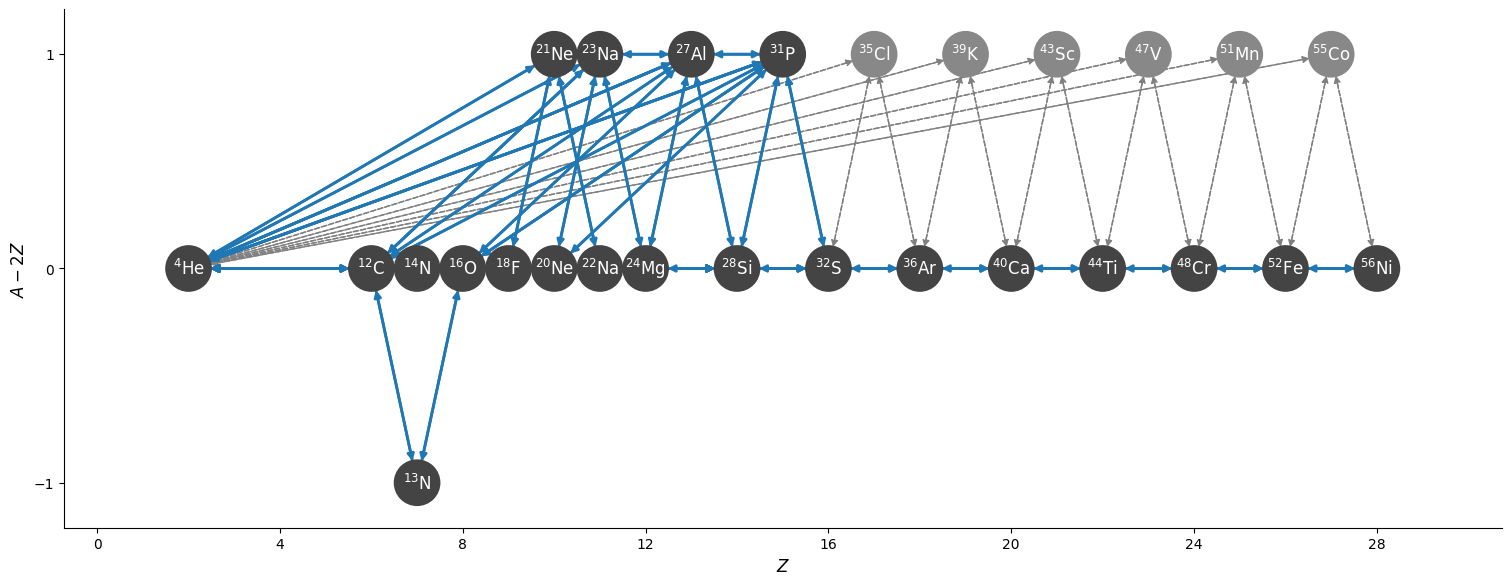

In [3]:
fig = net.plot(rotated=True, size=(1500,600), curved_edges=False)

In [6]:
net.write_network()
print(core_lib)

3 He4 ⟶ C12 + 𝛾                [Q =   7.28 MeV] (3 He4 --> C12 <fy05_reaclib__>)
C12 + p ⟶ N13 + 𝛾              [Q =   1.94 MeV] (C12 + p --> N13 <ls09_reaclib__>)
C12 + He4 ⟶ O16 + 𝛾            [Q =   7.16 MeV] (C12 + He4 --> O16 <nac2_reaclib__>)
C12 + C12 ⟶ He4 + Ne20         [Q =   4.62 MeV] (C12 + C12 --> He4 + Ne20 <cf88_reaclib__>)
C12 + C12 ⟶ p + Na23           [Q =   2.24 MeV] (C12 + C12 --> p + Na23 <cf88_reaclib__>)
C12 + C12 ⟶ Mg24 + 𝛾           [Q =  13.93 MeV] (C12 + C12 --> Mg24 <modified>)
N13 + He4 ⟶ p + O16            [Q =   5.22 MeV] (N13 + He4 --> p + O16 <cf88_reaclib__>)
N14 + He4 ⟶ F18 + 𝛾            [Q =   4.41 MeV] (N14 + He4 --> F18 <il10_reaclib__>)
O16 + He4 ⟶ Ne20 + 𝛾           [Q =   4.73 MeV] (O16 + He4 --> Ne20 <co10_reaclib__>)
O16 + C12 ⟶ He4 + Mg24         [Q =   6.77 MeV] (O16 + C12 --> He4 + Mg24 <cf88_reaclib__>)
O16 + C12 ⟶ p + Al27           [Q =   5.17 MeV] (O16 + C12 --> p + Al27 <cf88_reaclib__>)
O16 + C12 ⟶ Si28 + 𝛾           [Q =  16.76 MeV]